# Workshop 2: Train Je Eigen YOLO Model (Interactieve Versie)

Welkom bij de tweede workshop! In de vorige workshop heb je gezien hoe een **voorgetraind** YOLO model objecten kan herkennen. Nu gaan we een stap verder: **je gaat zelf een model trainen!**

## Wat is er anders aan deze versie?

Deze notebook is **interactief** - je gaat niet alleen code uitvoeren, maar ook:
- Voorspellen wat er gaat gebeuren
- Zelf code aanvullen
- Fouten opsporen
- Experimenteren met parameters
- Quizvragen beantwoorden

**Tip:** Neem de tijd voor de denkvragen. Even nadenken voordat je op 'Run' klikt zorgt voor beter begrip!

---

## Wat ga je leren?

1. Hoe een AI dataset eruitziet (afbeeldingen + labels)
2. Wat "transfer learning" is en waarom het zo krachtig is
3. Hoe je een YOLO model traint op je eigen data
4. Hoe je de resultaten evalueert
5. Je eigen model gebruiken voor realtime detectie!

---

## Stap 0: Setup Check

**Voer ALTIJD eerst deze cel uit!** Dit checkt of alles goed is ingesteld.

In [1]:
import sys
import os

print("=" * 70)
print("SETUP CHECK")
print("=" * 70)

# Check 1: Python versie
print("\n1. Python Versie Check")
print("-" * 70)
python_version = sys.version_info
print(f"   Python versie: {python_version.major}.{python_version.minor}.{python_version.micro}")
if python_version.major >= 3 and python_version.minor >= 8:
    print("   OK")
else:
    print("   FOUT - Je hebt minimaal Python 3.8 nodig")

# Check 2: Virtual Environment
print("\n2. Virtual Environment Check")
print("-" * 70)
in_venv = hasattr(sys, 'real_prefix') or (hasattr(sys, 'base_prefix') and sys.base_prefix != sys.prefix)
if in_venv:
    print("   OK - Je draait in een virtual environment!")
else:
    print("   WAARSCHUWING - Geen virtual environment gedetecteerd")
    print("   Tip: Maak eerst een venv aan (zie workshop 1)")

print("\n" + "=" * 70)
print("Setup check voltooid!")
print("=" * 70)

SETUP CHECK

1. Python Versie Check
----------------------------------------------------------------------
   Python versie: 3.12.10
   OK

2. Virtual Environment Check
----------------------------------------------------------------------
   OK - Je draait in een virtual environment!

Setup check voltooid!


---

## Stap 1: Importeer Libraries

De volgende cel laadt alle Python libraries die we nodig hebben. Als je hier een foutmelding krijgt, moet je eerst `pip install -r requirements.txt` uitvoeren in je terminal.

In [2]:
import cv2
import os
import sys
import random
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
import yaml

print("Libraries succesvol geimporteerd!")
print(f"\nJe gebruikt:")
print(f"   - Python {sys.version.split()[0]}")
print(f"   - OpenCV {cv2.__version__}")

Libraries succesvol geimporteerd!

Je gebruikt:
   - Python 3.12.10
   - OpenCV 4.13.0


---

## Configuratie

In het blok hieronder staan **alle instellingen** voor deze workshop op een centrale plek.

Door ze hier bovenaan te zetten kun je ze makkelijk terugvinden en aanpassen. De rest van de notebook verwijst naar deze waarden - zo hoef je nooit te zoeken waar een getal vandaan komt.

**Voor nu hoef je hier niets aan te passen** - de standaardwaarden zijn goed voor deze workshop. Later kun je hier terugkomen om te experimenteren!

In [4]:
# ============================================================
# CONFIGURATIE - Alle instellingen voor deze workshop
# ============================================================
# Alle waarden die de notebook gebruikt staan hier.
# Je hoeft alleen hier iets aan te passen - de rest van de
# notebook gebruikt deze waarden automatisch.
# ============================================================

# --- Dataset pad ---
# De dataset staat in de 'dataset' map naast dit notebook.
# Als je een eigen dataset hebt, pas dan dit pad aan.

if os.path.exists("dataset"):
    DATASET_PATH = os.path.abspath("dataset")
else:
    DATASET_PATH = "NIET GEVONDEN"  # Pas dit handmatig aan als de dataset ergens anders staat

# Afgeleide paden (worden automatisch berekend op basis van DATASET_PATH)
TRAIN_IMAGES_PATH = os.path.join(DATASET_PATH, "train", "images")
TRAIN_LABELS_PATH = os.path.join(DATASET_PATH, "train", "labels")
TEST_IMAGES_PATH  = os.path.join(DATASET_PATH, "test", "images")
DATA_YAML_PATH    = os.path.abspath(os.path.join(DATASET_PATH, "data.yaml"))

# --- Training parameters ---
# Deze bepalen hoe het model getraind wordt.
# Omdat we op CPU werken wat meer trainingtijd kost is gekozen voor minimale trainingsparameters
MODEL_SIZE  = "yolov8n.pt"  # Welk startmodel? n=nano(snel), s=small, m=medium, l=large
EPOCHS      = 10            # Hoe vaak door alle trainingsdata? Meer = beter, maar duurt langer
IMAGE_SIZE  = 320           # Afbeeldingsgrootte in pixels. Groter = nauwkeuriger maar trager
BATCH_SIZE  = 4             # Hoeveel afbeeldingen tegelijk verwerken? Lager = minder geheugen
DEVICE      = "cpu"         # "cpu" of 0 voor NVIDIA GPU

# --- Detectie instellingen ---
CONFIDENCE_THRESHOLD = 0.5  # Hoe zeker moet het model zijn? (0.0 tot 1.0)
                            #   Laag  (0.1) = veel detecties, ook onzekere
                            #   Hoog  (0.8) = weinig maar betrouwbare detecties

# --- Camera instellingen ---
CAMERA_INDEX = 0            # 0 = standaard webcam, 1 = tweede camera, enz.

# --- Kleuren voor visualisatie (BGR format, want OpenCV gebruikt BGR) ---
COLORS = {
    0: (0, 255, 0),    # bolt (bout) = groen
    1: (255, 0, 0),    # nut (moer)  = rood
}

# ============================================================
# Check of alles klopt
# ============================================================
print("Configuratie geladen!")
print("=" * 70)

if os.path.exists(DATASET_PATH):
    print(f"   Dataset:     {DATASET_PATH}")
    for folder in ['train', 'valid', 'test']:
        folder_path = os.path.join(DATASET_PATH, folder, "images")
        if os.path.exists(folder_path):
            count = len([f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png'))])
            print(f"                - {folder}: {count} afbeeldingen")
else:
    print(f"   FOUT: Dataset niet gevonden op: {DATASET_PATH}")
    print(f"   Pas DATASET_PATH hierboven aan.")

print(f"\n   Model:       {MODEL_SIZE}")
print(f"   Epochs:      {EPOCHS}")
print(f"   Image size:  {IMAGE_SIZE}px")
print(f"   Device:      {DEVICE}")
print(f"   Confidence:  {CONFIDENCE_THRESHOLD}")
print(f"   Camera:      {CAMERA_INDEX}")
print("=" * 70)

Configuratie geladen!
   Dataset:     c:\0-projecten\AIC4NL\Track-Vision\Workshops\Beginner\Workshop 2 - YOLO trainen\dataset
                - train: 396 afbeeldingen
                - valid: 72 afbeeldingen
                - test: 82 afbeeldingen

   Model:       yolov8n.pt
   Epochs:      10
   Image size:  320px
   Device:      cpu
   Confidence:  0.5
   Camera:      0


---

## Stap 2: Verken de Dataset

Voordat we gaan trainen, gaan we eerst kijken naar de data waarmee het model gaat leren.

### Hoe werkt een dataset?

Een YOLO dataset bestaat uit:
1. **Afbeeldingen** - De foto's waarop objecten staan
2. **Labels** - Tekstbestanden die vertellen WAT en WAAR objecten zijn

### De mappenstructuur:

```
dataset/
    train/          <- Voor training (70-80%)
        images/     <- Foto's
        labels/     <- Labels (txt bestanden)
    valid/          <- Voor validatie (10-15%)
        images/
        labels/
    test/           <- Voor testen (10-15%)
        images/
        labels/
    data.yaml       <- Configuratiebestand
```

---

## DENKVRAAG 1

Voordat je de volgende cel uitvoert, beantwoord deze vraag:

**Waarom denk je dat we de data splitsen in train, valid en test?**

Schrijf je antwoord hieronder (dubbelklik om te bewerken):

> *Jouw antwoord:* ...

De volgende cel leest het `data.yaml` configuratiebestand. Dit bestand vertelt YOLO welke classes (objecttypes) er in de dataset zitten.

**Verwachte output:** Een overzicht van de classes en het aantal afbeeldingen per set.

In [5]:
# Lees het data.yaml configuratiebestand
with open(DATA_YAML_PATH, 'r') as f:
    data_config = yaml.safe_load(f)

CLASS_NAMES = data_config['names']

print("Classes die we gaan herkennen:")
print("-" * 40)
for i, name in enumerate(CLASS_NAMES):
    print(f"   {i}: {name}")
print(f"\nTotaal: {data_config['nc']} classes")

Classes die we gaan herkennen:
----------------------------------------
   0: bolt
   1: nut

Totaal: 2 classes


### Antwoord op Denkvraag 1

<details>
<summary>Klik hier voor het antwoord</summary>

We splitsen de data in drie sets om **overfitting** te voorkomen en eerlijk te evalueren:

- **Train (70-80%)**: Hiervan leert het model. Het ziet deze afbeeldingen meerdere keren.
- **Validation (10-15%)**: Tijdens training checken we hiermee hoe goed het model generaliseert naar "nieuwe" data. Dit helpt bij het kiezen van de beste model-versie.
- **Test (10-15%)**: Deze data raakt het model NOOIT tijdens training. Pas aan het einde testen we hier op.

**Analogie**: Train = oefentoetsen, Validation = proefexamen, Test = het echte examen!

**Overfitting**: Het model leert de trainingsdata *te goed* - het leert specifieke afbeeldingen uit zijn hoofd in plaats van algemene patronen. Net als een student die antwoorden van oude toetsen uit het hoofd leert, maar bij een andere versie van dezelfde toets niet de goede antwoorden kan geven.

</details>

---

### Bekijk voorbeelden uit de dataset

De volgende cel toont 4 willekeurige afbeeldingen uit de trainingsset, zodat je ziet waar het model mee gaat leren.

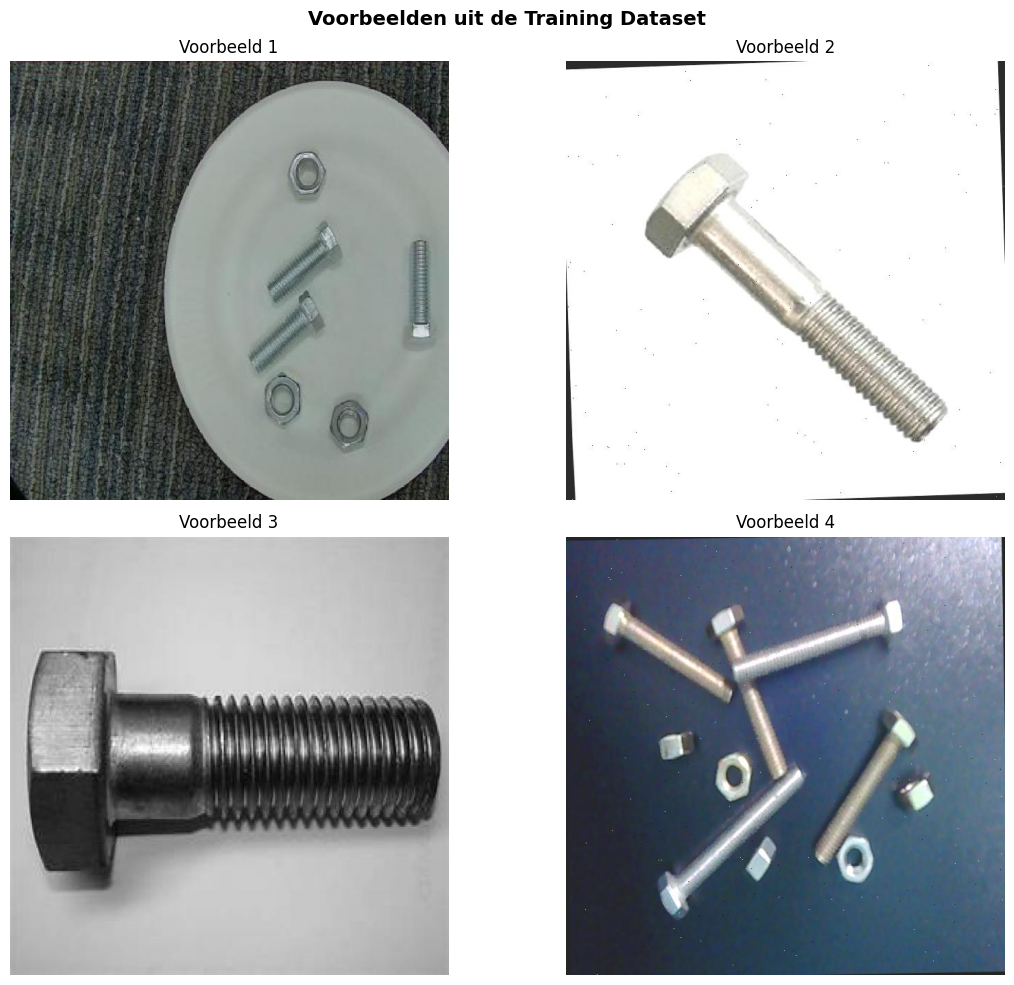

Dit zijn afbeeldingen van bouten en moeren.
Het model gaat leren om deze te herkennen!


In [6]:
images = [f for f in os.listdir(TRAIN_IMAGES_PATH) if f.endswith(('.jpg', '.png'))]
sample_images = random.sample(images, min(4, len(images)))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, img_name in enumerate(sample_images):
    img_path = os.path.join(TRAIN_IMAGES_PATH, img_name)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[idx].imshow(img_rgb)
    axes[idx].set_title(f"Voorbeeld {idx+1}", fontsize=12)
    axes[idx].axis('off')

plt.suptitle("Voorbeelden uit de Training Dataset", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Dit zijn afbeeldingen van bouten en moeren.")
print("Het model gaat leren om deze te herkennen!")

---

### Hoe ziet een label eruit?

Bij elke afbeelding hoort een **label-bestand** (een `.txt` bestand). Dit bestand vertelt het model waar de objecten zitten.

Elk label heeft dit format:

```
class_id  x_center  y_center  width  height
```

**Voorbeeld:** `1 0.50 0.40 0.20 0.15`

Wat betekent dit?
- `1` = het is een **nut** (moer). (`0` zou een **bolt** (bout) zijn)
- `0.50` = het centrum van het object zit op **50%** van de breedte (= horizontaal in het midden)
- `0.40` = het centrum zit op **40%** van de hoogte (= iets boven het midden)
- `0.20` = het object is **20%** van de beeldbreedte breed
- `0.15` = het object is **15%** van de beeldhoogte hoog

Alle waarden zijn **genormaliseerd** (tussen 0 en 1) - meer hierover in de volgende denkvraag!

---

## DENKVRAAG 2

**Waarom zou het handig zijn dat de coordinaten genormaliseerd zijn (waarden tussen 0 en 1) in plaats van in pixels?**

**Hint:** Stel je voor dat je dezelfde afbeelding hebt in twee formaten: 320x320 pixels en 1920x1080 pixels. Wat zou er met de labels gebeuren als ze in pixels waren?

> *Jouw antwoord:* ...

De volgende cel leest het label-bestand dat bij de eerste voorbeeldafbeelding hoort en laat de inhoud zien.

**Verwachte output:** Regels met getallen - elke regel is een object in de afbeelding.

In [7]:
# Bekijk een echt label uit onze dataset
example_img = sample_images[0]
label_name = example_img.replace('.jpg', '.txt').replace('.png', '.txt')
label_path = os.path.join(TRAIN_LABELS_PATH, label_name)

print(f"Afbeelding: {example_img}")
print(f"Label bestand: {label_name}")
print("\n" + "-" * 70)
print("Inhoud van het label bestand:")
print("-" * 70)

if os.path.exists(label_path):
    with open(label_path, 'r') as f:
        content = f.read()
    print(content)
    
    print("Uitleg:")
    print("-" * 70)
    for line in content.strip().split('\n'):
        parts = line.split()
        if len(parts) >= 5:
            class_id = int(parts[0])
            class_name = CLASS_NAMES[class_id]
            print(f"   Class {class_id} ({class_name}): centrum=({parts[1]}, {parts[2]}), grootte=({parts[3]} x {parts[4]})")
else:
    print("Label bestand niet gevonden")

Afbeelding: nut-bolt-train_090_jpg.rf.5d599ca2a8efeb910b7385565179f2ce.jpg
Label bestand: nut-bolt-train_090_jpg.rf.5d599ca2a8efeb910b7385565179f2ce.txt

----------------------------------------------------------------------
Inhoud van het label bestand:
----------------------------------------------------------------------
0 0.93359375 0.5375 0.096875 0.29375
0 0.6296875 0.62109375 0.2046875 0.2046875
0 0.66953125 0.45546875 0.18125 0.209375
1 0.67890625 0.25859375 0.09375 0.1140625
1 0.62265625 0.78515625 0.1015625 0.159375
1 0.771875 0.83046875 0.1109375 0.1453125
Uitleg:
----------------------------------------------------------------------
   Class 0 (bolt): centrum=(0.93359375, 0.5375), grootte=(0.096875 x 0.29375)
   Class 0 (bolt): centrum=(0.6296875, 0.62109375), grootte=(0.2046875 x 0.2046875)
   Class 0 (bolt): centrum=(0.66953125, 0.45546875), grootte=(0.18125 x 0.209375)
   Class 1 (nut): centrum=(0.67890625, 0.25859375), grootte=(0.09375 x 0.1140625)
   Class 1 (nut): cen

### Antwoord op Denkvraag 2

<details>
<summary>Klik hier voor het antwoord</summary>

Genormaliseerde coordinaten (0-1) maken het label **onafhankelijk van de afbeeldingsgrootte**!

- `x_center = 0.5` betekent "horizontaal in het midden", of de afbeelding nu 320px of 1920px breed is
- Bij pixel-coordinaten zou je voor elke resolutie alle labels opnieuw moeten berekenen
- Tijdens training worden afbeeldingen vaak vergroot/verkleind - met genormaliseerde waarden hoeven de labels niet mee te veranderen

</details>

---

### Labels visualiseren

YOLO rekent de genormaliseerde waarden automatisch om naar pixels en tekent er bounding boxes van. Maar het is handig om zelf te **zien** hoe de labels eruitzien op de afbeelding.

De volgende cel doet precies wat YOLO onder de motorkap doet: de labels uitlezen en als gekleurde vakjes op de afbeelding tekenen.

In [ ]:
# Teken de labels op de afbeelding

img_path = os.path.join(TRAIN_IMAGES_PATH, example_img)
img = cv2.imread(img_path)
img_with_labels = img.copy()
h, w = img.shape[:2]

# Lees de labels en teken bounding boxes
with open(label_path, 'r') as f:
    labels = f.readlines()

for label in labels:
    parts = label.strip().split()
    if len(parts) >= 5:
        class_id = int(parts[0])
        
        # Omrekenen: genormaliseerd (0-1) naar pixels
        x_center = float(parts[1]) * w
        y_center = float(parts[2]) * h
        box_w = float(parts[3]) * w
        box_h = float(parts[4]) * h
        
        # Van centrum+grootte naar hoekpunten
        x1 = int(x_center - box_w / 2)
        y1 = int(y_center - box_h / 2)
        x2 = int(x_center + box_w / 2)
        y2 = int(y_center + box_h / 2)
        
        # Teken rechthoek en label
        color = COLORS.get(class_id, (255, 255, 255))
        cv2.rectangle(img_with_labels, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img_with_labels, CLASS_NAMES[class_id], (x1, y1 - 5),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

# Toon het resultaat
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("1. Originele Afbeelding", fontsize=12)
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_with_labels, cv2.COLOR_BGR2RGB))
axes[1].set_title("2. Met Labels Getekend", fontsize=12)
axes[1].axis('off')

plt.suptitle("Van Label-bestand naar Visuele Annotatie", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Links: de originele foto. Rechts: dezelfde foto met de labels als gekleurde vakjes.")
print("Groen = bolt (bout), Rood = nut (moer)")

---

## CODE QUIZ: Kun je de Code Lezen?

Je hebt net code gezien die labels op een afbeelding tekent. Laten we checken of je de code kunt "lezen" - net als bij een nieuwe taal begint het met luisteren en begrijpen!

**Vraag 1:** De regel `h, w = img.shape[:2]` geeft ons twee waarden. Wat zijn `h` en `w`?

- A) De hoogte en breedte van de afbeelding in pixels
- B) De breedte en hoogte van de afbeelding in pixels
- C) Het aantal objecten en het aantal kleuren

> *Jouw antwoord:* ...

**Vraag 2:** We gebruiken `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` voordat we de afbeelding tonen met matplotlib. Wat gebeurt er als je dit weglaat?

- A) De afbeelding wordt niet getoond
- B) De afbeelding toont, maar rood en blauw zijn verwisseld
- C) De afbeelding wordt zwart-wit

> *Jouw antwoord:* ...

**Vraag 3:** De code gebruikt `COLORS.get(class_id, (255, 255, 255))`. Wat doet het stuk `(255, 255, 255)` hier?

- A) Het is de standaardkleur voor alle bounding boxes
- B) Het zorgt ervoor dat de code crasht bij een onbekende class
- C) Het is een fallback-kleur (wit) voor als de class_id niet in COLORS staat

> *Jouw antwoord:* ...

<details>
<summary>Antwoorden</summary>

**Vraag 1: A** - `img.shape` geeft `(hoogte, breedte, kanalen)`. Met `[:2]` pakken we de eerste twee: hoogte en breedte. Let op de volgorde: het is hoogte x breedte, NIET breedte x hoogte!

**Vraag 2: B** - OpenCV slaat kleuren op als BGR (blauw-groen-rood), maar matplotlib verwacht RGB (rood-groen-blauw). Zonder conversie zijn rood en blauw verwisseld - je ziet blauwe tomaten en rode luchten!

**Vraag 3: C** - `.get(key, default)` is een veilige manier om iets uit een dictionary te halen. Als de key niet bestaat, krijg je de default-waarde terug in plaats van een crash. Hier wordt dat wit (255, 255, 255).

</details>

---

## Stap 3: Begrijp Transfer Learning

### Waarom niet vanaf nul trainen?

Een AI model vanaf nul trainen zou:
- Duizenden afbeeldingen nodig hebben
- Dagen tot weken duren
- Veel rekenkracht vereisen

### De oplossing: Transfer Learning

**Transfer Learning** betekent: we beginnen met een model dat al "geleerd" heeft om te zien!

Het YOLOv8 model is getraind op miljoenen afbeeldingen en kan al:
- Randen en vormen herkennen
- Texturen onderscheiden  
- Objecten van achtergrond scheiden

Wij hoeven het model alleen nog te leren: "dit specifieke ding is een bout, dat is een moer".

**Resultaat:** Met slechts honderden afbeeldingen krijg je al goede resultaten!

---

## QUIZ 1: Transfer Learning

**Vraag 1:** Als je een model vanaf nul traint, wat moet het dan allemaal leren?

- A) Alles: randen, vormen, texturen, en dan pas de specifieke objecten
- B) Alleen de specifieke objecten (bouten/moeren)
- C) Niets, het model weet al alles

> *Jouw antwoord:* ...

**Vraag 2:** Bij transfer learning, welk deel van het model passen we vooral aan?

- A) Het hele model wordt compleet opnieuw getraind
- B) Alleen de eerste lagen, die randen herkennen
- C) Vooral de laatste lagen, die specifieke objecten herkennen

> *Jouw antwoord:* ...

**Vraag 3:** Hoeveel afbeeldingen heb je ongeveer nodig met transfer learning?

- A) Miljoenen
- B) Honderden tot duizenden
- C) 5 tot 10

> *Jouw antwoord:* ...

### Antwoorden Quiz 1

<details>
<summary>Klik hier voor de antwoorden</summary>

**Vraag 1: A** - Vanaf nul moet het model ALLES leren: eerst basisvormen, dan complexere patronen, en dan pas specifieke objecten.

**Vraag 2: C** - Bij transfer learning houden we de "kennis" over basisvormen en passen we vooral de laatste lagen aan die specifieke objecten herkennen.

**Vraag 3: B** - Met transfer learning heb je typisch honderden tot duizenden afbeeldingen nodig. In onze workshop gebruiken we ~400 training afbeeldingen.

</details>

---

## Stap 4: Train het Model!

Nu komt het spannende deel - we gaan trainen!

De parameters uit het **Configuratie blok** worden hier gebruikt. Als je later wilt experimenteren, pas je de waarden daar aan.

| Parameter | Waarde | Uitleg |
|-----------|--------|--------|
| `MODEL_SIZE` | yolov8n.pt | Nano model (kleinste, snelste) |
| `EPOCHS` | 10 | Aantal keer door de dataset |
| `IMAGE_SIZE` | 320 | Afbeeldingsgrootte (kleiner = sneller) |
| `DEVICE` | cpu | We trainen op CPU |
| `BATCH_SIZE` | 4 | Aantal afbeeldingen per stap |

### Wat betekenen de getallen tijdens training?

| Metric | Wat meet het? | Goed teken |
|--------|---------------|------------|
| **box_loss** | Hoe goed de locatie van de vakjes klopt | Dalend |
| **cls_loss** | Hoe goed het model de juiste class kiest (bolt vs nut) | Dalend |
| **mAP50** | Overall score - hoe nauwkeurig zijn de detecties? | Stijgend (max 1.0) |

---

## DENKVRAAG 3: Voorspellen

Voordat je de training start, maak een voorspelling:

**Wat verwacht je dat er gebeurt met de "loss" (fout) naarmate de training vordert?**

- A) De loss begint hoog en daalt geleidelijk
- B) De loss begint laag en stijgt geleidelijk  
- C) De loss blijft constant
- D) De loss springt willekeurig op en neer

> *Jouw voorspelling:* ...

**Waarom denk je dat? Denk aan wat "loss" betekent (= de fout die het model maakt).**

> *Jouw redenering:* ...

De volgende cel start de training. Dit duurt **enkele minuten** op CPU. Je ziet de voortgang per epoch.

**Let op de getallen:** de loss-waarden moeten per epoch dalen, de mAP-waarden moeten stijgen.

In [ ]:
# TRAINING - Dit is waar de magie gebeurt!
# Alle parameters komen uit het Configuratie blok bovenaan.

print("=" * 70)
print("START TRAINING")
print("=" * 70)
print(f"\nModel: {MODEL_SIZE}, Epochs: {EPOCHS}, Image size: {IMAGE_SIZE}, Device: {DEVICE}")
print("Dit kan enkele minuten duren op CPU...\n")

model = YOLO(MODEL_SIZE)

training_results = model.train(
    data=DATA_YAML_PATH,
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    patience=5,
    save=True,
    project='runs/detect',
    name='bouten_moeren',
    exist_ok=True,
    verbose=True
)

results_path = str(training_results.save_dir)

print("\n" + "=" * 70)
print("TRAINING VOLTOOID!")
print("=" * 70)
print(f"\nResultaten opgeslagen in: {results_path}")

### Antwoord Denkvraag 3

<details>
<summary>Klik hier voor het antwoord</summary>

**Het juiste antwoord is A**: De loss begint hoog en daalt geleidelijk.

**Waarom?**
- In het begin maakt het model veel fouten (hoge loss)
- Elke epoch leert het model van zijn fouten en past het zijn gewichten aan
- De fouten (loss) worden daardoor steeds kleiner
- Uiteindelijk stabiliseert de loss als het model "uitgeleerd" is

Je ziet misschien wat kleine schommelingen, maar de algemene trend moet dalend zijn!

</details>

---

## REFLECTIE: Training Observaties

Nu je de training hebt gezien, beantwoord deze vragen:

**1. Klopte je voorspelling over de loss?**

> *Jouw antwoord:* ...

**2. Wat viel je op aan de getallen tijdens de training? Ging het ergens sneller of langzamer?**

> *Jouw observaties:* ...

**3. Was de training snel of langzaam? Welke parameters (uit het Configuratie blok) zouden dit beinvloeden?**

> *Jouw antwoord:* ...

---

## CODE QUIZ: Begrijp de Training Code

Voordat we de resultaten bekijken, even checken of je de training code begrijpt.

**Vraag 1:** In de training staat `imgsz=IMAGE_SIZE` (320). Wat betekent dit?

- A) Er worden maximaal 320 afbeeldingen gebruikt
- B) Alle afbeeldingen worden verkleind naar 320x320 pixels voor training
- C) Het model kan alleen objecten kleiner dan 320 pixels detecteren

> *Jouw antwoord:* ...

**Vraag 2:** De parameter `patience=5` zorgt ervoor dat...

- A) De training maximaal 5 minuten duurt
- B) Het model 5 keer opnieuw traint als het niet goed genoeg is
- C) De training eerder stopt als het model 5 epochs lang niet verbetert

> *Jouw antwoord:* ...

**Vraag 3:** Na training laden we `best.pt` in plaats van `last.pt`. Waarom?

- A) `best.pt` is het model van de epoch met de beste validatie-score
- B) `last.pt` bevat altijd fouten
- C) `best.pt` is kleiner en sneller

> *Jouw antwoord:* ...

<details>
<summary>Antwoorden</summary>

**Vraag 1: B** - Alle trainingsafbeeldingen worden geresized naar 320x320 pixels. Kleinere afbeeldingen = snellere training, maar minder detail.

**Vraag 2: C** - "Early stopping": als de validatie-score 5 epochs lang niet verbetert, stopt de training automatisch. Dit bespaart tijd en voorkomt overfitting.

**Vraag 3: A** - Tijdens training slaat YOLO het model op bij elke verbetering. `best.pt` is de versie met de beste validatie-score, niet per se de laatste epoch.

</details>

---

## Stap 5: Bekijk de Resultaten

### Wat is een Confusion Matrix?

Een **Confusion Matrix** (verwarringsmatrix) laat in een tabel zien hoe goed het model presteert.

**Zo lees je hem:**
- De **rijen** = wat het object **werkelijk** is
- De **kolommen** = wat het model **voorspelt**
- Op de **diagonaal** (linksboven naar rechtsonder) staan de **correcte** voorspellingen
- Alles **buiten de diagonaal** zijn **fouten**

**Voorbeeld:**

| | Voorspeld: bolt | Voorspeld: nut | Voorspeld: achtergrond |
|---|---|---|---|
| **Werkelijk: bolt** | 0.85 (goed!) | 0.05 (verward) | 0.10 (gemist) |
| **Werkelijk: nut** | 0.03 (verward) | 0.90 (goed!) | 0.07 (gemist) |

In dit voorbeeld:
- 85% van de bouten wordt correct herkend
- 5% van de bouten wordt per ongeluk als moer bestempeld
- 10% van de bouten wordt helemaal gemist (achtergrond)

In [ ]:
# Toon de Confusion Matrix

confusion_matrix_path = os.path.join(results_path, "confusion_matrix_normalized.png")
if not os.path.exists(confusion_matrix_path):
    confusion_matrix_path = os.path.join(results_path, "confusion_matrix.png")

if os.path.exists(confusion_matrix_path):
    img = plt.imread(confusion_matrix_path)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title("Confusion Matrix van jouw Model", fontsize=14)
    plt.axis('off')
    plt.show()
else:
    print(f"Confusion matrix niet gevonden in: {results_path}")

---

## OPDRACHT 2: Lees de Confusion Matrix

Bekijk de confusion matrix hierboven. Gebruik de uitleg van het voorbeeld om deze vragen te beantwoorden:

**1. Kijk naar de diagonaal (de vakjes linksboven naar rechtsonder). Welk object heeft het hoogste getal op de diagonaal: bolt of nut?** Dat object wordt het beste herkend.

> *Jouw antwoord:* ...

**2. Kijk naar het vakje waar de rij "bolt" en de kolom "nut" kruisen. Is dit getal hoog of laag?** Een hoog getal betekent dat het model bouten vaak verwart met moeren.

> *Jouw antwoord:* ...

**3. De kolom/rij "background" gaat over objecten die het model heeft gemist (het dacht dat het achtergrond was). Worden er veel objecten gemist?**

> *Jouw antwoord:* ...

De volgende cel toont de **training curves**: grafieken die laten zien hoe het model beter werd gedurende de training.

In [ ]:
# Toon de training curves

results_img_path = os.path.join(results_path, "results.png")

if os.path.exists(results_img_path):
    img = plt.imread(results_img_path)
    plt.figure(figsize=(14, 10))
    plt.imshow(img)
    plt.title("Training Curves - De Leervoortgang van je Model", fontsize=14)
    plt.axis('off')
    plt.show()
    
    print("Wat zie je hier?")
    print("-" * 70)
    print("LOSS grafieken (links) - moeten DALEN (minder fouten)")
    print("METRICS grafieken (rechts) - moeten STIJGEN (betere nauwkeurigheid)")
else:
    print(f"Training curves niet gevonden in: {results_path}")

---

## Stap 6: Test je Model

We laden het beste model dat tijdens training is opgeslagen en testen het op afbeeldingen die het model **nog nooit heeft gezien** (de test set).

In [ ]:
# Laad het beste model

best_model_path = os.path.join(results_path, "weights", "best.pt")
last_model_path = os.path.join(results_path, "weights", "last.pt")

if os.path.exists(best_model_path):
    print(f"Beste model gevonden: {best_model_path}")
    trained_model = YOLO(best_model_path)
elif os.path.exists(last_model_path):
    print(f"Laatste model gevonden: {last_model_path}")
    trained_model = YOLO(last_model_path)
else:
    print("Geen getraind model gevonden - gebruik het basis model")
    trained_model = model

print(f"Het model kan herkennen: {list(trained_model.names.values())}")

De volgende cel test het model op 4 willekeurige afbeeldingen uit de test set. Het model gebruikt de `CONFIDENCE_THRESHOLD` uit het Configuratie blok.

**Verwacht resultaat:** Afbeeldingen met gekleurde vakjes rond herkende objecten en een percentage dat aangeeft hoe zeker het model is.

In [ ]:
# Test op afbeeldingen uit de test set

test_images = [f for f in os.listdir(TEST_IMAGES_PATH) if f.endswith(('.jpg', '.png'))]
sample_test = random.sample(test_images, min(4, len(test_images)))

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

print(f"Test resultaten (confidence threshold: {CONFIDENCE_THRESHOLD}):")
print("=" * 70)

for idx, img_name in enumerate(sample_test):
    img_path = os.path.join(TEST_IMAGES_PATH, img_name)
    results = trained_model(img_path, conf=CONFIDENCE_THRESHOLD, verbose=False)
    
    annotated = results[0].plot()
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    
    num_detections = len(results[0].boxes)
    axes[idx].imshow(annotated_rgb)
    axes[idx].set_title(f"Test {idx+1}: {num_detections} object(en)", fontsize=12)
    axes[idx].axis('off')
    
    print(f"\nAfbeelding {idx+1}: {num_detections} detecties")
    for box in results[0].boxes:
        class_name = trained_model.names[int(box.cls[0])]
        confidence = float(box.conf[0])
        print(f"   - {class_name}: {confidence*100:.1f}%")

plt.suptitle("Resultaten op Test Afbeeldingen", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## EXPERIMENT: Confidence Threshold

De `CONFIDENCE_THRESHOLD` (uit het Configuratie blok) bepaalt hoe **zeker** het model moet zijn voordat het een detectie toont.

- `0.1` = "Toon alles waar het model minimaal 10% zeker van is" (veel detecties, ook onzekere)
- `0.5` = "Toon alleen detecties waar het model minimaal 50% zeker van is"
- `0.8` = "Toon alleen detecties waar het model zeer zeker van is" (weinig, maar betrouwbaar)

**Opdracht:**
1. Verander `experiment_conf` in de cel hieronder naar `0.1` en voer uit
2. Verander naar `0.5` en voer opnieuw uit
3. Verander naar `0.8` en voer opnieuw uit

**Kijk bij elke run naar:**
- Hoeveel detecties zijn er?
- Zijn alle detecties correct, of zitten er fouten tussen?
- Worden alle objecten gevonden?

In [ ]:
# EXPERIMENT: Verander experiment_conf en run opnieuw!
# (Dit verandert NIET de CONFIDENCE_THRESHOLD uit het config blok)

experiment_conf = 0.3  # <-- VERANDER DIT GETAL: probeer 0.1, 0.5 en 0.8

test_img_path = os.path.join(TEST_IMAGES_PATH, random.choice(test_images))
results = trained_model(test_img_path, conf=experiment_conf, verbose=False)

annotated = results[0].plot()
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(annotated_rgb)
plt.title(f"Confidence: {experiment_conf} - Detecties: {len(results[0].boxes)}", fontsize=14)
plt.axis('off')
plt.show()

print(f"Met conf={experiment_conf}:")
print(f"   Aantal detecties: {len(results[0].boxes)}")
for box in results[0].boxes:
    class_name = trained_model.names[int(box.cls[0])]
    confidence = float(box.conf[0])
    print(f"   - {class_name}: {confidence*100:.1f}%")

### Observaties Experiment

Noteer wat je zag bij de verschillende waarden:

| Threshold | Aantal detecties | Waren alle detecties correct? |
|-----------|-----------------|-------------------------------|
| 0.1 | ... | ... |
| 0.5 | ... | ... |
| 0.8 | ... | ... |

**Conclusie:** Er is een afweging ("trade-off"):
- Lage threshold = meer objecten gevonden, maar ook meer foute detecties
- Hoge threshold = minder fouten, maar je mist objecten
- De beste waarde hangt af van je toepassing!

---

## DEBUG CHALLENGE

De volgende code bevat **3 fouten**. Kun je ze vinden en fixen?

De code zou een afbeelding moeten laden, detectie moeten uitvoeren, en het resultaat moeten tonen.

**Tips om fouten te vinden:**
- **Run de code eerst!** De foutmelding vertelt je vaak precies wat er mis is
- Vergelijk met de werkende code hierboven - wat is er anders?
- Let op: aanhalingstekens, types (getal vs tekst), en hoe je met lijsten werkt

**Hints per fout:**
1. Een van de parameters heeft het verkeerde type (tekst in plaats van een getal)
2. Het model geeft een lijst terug - je kunt niet zomaar `.plot()` op een hele lijst aanroepen
3. De kleurconversie gaat de verkeerde kant op

In [ ]:
# DEBUG CHALLENGE - Vind en fix de 3 fouten!
# Tip: run de cel, lees de foutmelding, en pas de code aan.

# Laad een test afbeelding
img_path = os.path.join(TEST_IMAGES_PATH, test_images[0])

# FOUT 1: Kijk goed naar de waarde van conf - wat voor type moet dit zijn?
results = trained_model.predict(img_path, conf="0.3", verbose=False)

# FOUT 2: results is een lijst (meerdere afbeeldingen). Hoe pak je het eerste element?
annotated = results.plot()

# FOUT 3: OpenCV slaat kleuren op als BGR. Matplotlib verwacht RGB.
#          Welke richting moet de conversie op?
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR)

# Toon het resultaat
plt.figure(figsize=(10, 8))
plt.imshow(annotated_rgb)
plt.title("Debug Challenge Resultaat")
plt.axis('off')
plt.show()

### Oplossing Debug Challenge

<details>
<summary>Klik hier voor de oplossing</summary>

**Fout 1:** `conf="0.3"` - conf moet een **getal** (float) zijn, geen **tekst** (string)!
```python
# Fout:   conf="0.3"    <- dit is tekst (let op de aanhalingstekens)
# Correct: conf=0.3     <- dit is een getal
```

**Fout 2:** `results.plot()` - results is een **lijst**. Je moet het eerste (en enige) element pakken met `[0]`.
```python
# Fout:   results.plot()       <- je kunt niet .plot() op een lijst doen
# Correct: results[0].plot()   <- pak het eerste element, dan .plot()
```

**Fout 3:** De conversie gaat de verkeerde kant op. OpenCV geeft **BGR**, matplotlib wil **RGB**.
```python
# Fout:   cv2.COLOR_RGB2BGR  <- dit converteert van RGB NAAR BGR (verkeerde richting!)
# Correct: cv2.COLOR_BGR2RGB  <- dit converteert van BGR NAAR RGB
```

</details>

---

## Stap 7: Realtime Detectie met je Eigen Model!

Nu het spannendste moment: test je eigen model met de webcam!

De webcam gebruikt `CAMERA_INDEX` en `CONFIDENCE_THRESHOLD` uit het Configuratie blok. Merk je veel foute detecties? Ga terug naar het config blok en verhoog `CONFIDENCE_THRESHOLD`.

In [ ]:
# REALTIME DETECTIE MET JE EIGEN MODEL!
# Gebruikt CAMERA_INDEX en CONFIDENCE_THRESHOLD uit het Configuratie blok.

print("Starten realtime detectie met je getrainde model...")
print(f"Camera: {CAMERA_INDEX}, Confidence: {CONFIDENCE_THRESHOLD}")
print("\nTips:")
print("   - Een nieuw venster opent zich")
print("   - Houd bouten/moeren voor de camera (of afbeeldingen op je telefoon!)")
print("   - Druk 'q' in het venster om te stoppen")
print("   - Of wacht 60 seconden voor auto-stop\n")

if sys.platform == 'win32':
    cap = cv2.VideoCapture(CAMERA_INDEX, cv2.CAP_DSHOW)
else:
    cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Kan camera niet openen!")
    print(f"Tip: probeer een andere CAMERA_INDEX in het Configuratie blok (nu: {CAMERA_INDEX})")
else:
    print("Camera geopend! Venster opent zich nu...\n")
    
    frame_count = 0
    start_time = time.time()
    fps = 0
    timeout = 60
    
    while True:
        if time.time() - start_time > timeout:
            print(f"\nAutomatische stop na {timeout} seconden")
            break
        
        ret, frame = cap.read()
        if not ret:
            print("Kan geen frame lezen!")
            break
        
        results = trained_model(frame, conf=CONFIDENCE_THRESHOLD, verbose=False)
        annotated_frame = results[0].plot()
        
        current_bolts = sum(1 for box in results[0].boxes if trained_model.names[int(box.cls[0])] == 'bolt')
        current_nuts = sum(1 for box in results[0].boxes if trained_model.names[int(box.cls[0])] == 'nut')
        
        frame_count += 1
        if frame_count % 10 == 0:
            fps = frame_count / (time.time() - start_time)
        
        cv2.putText(annotated_frame, f"FPS: {fps:.1f}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        cv2.putText(annotated_frame, f"Bouten: {current_bolts}  Moeren: {current_nuts}", (10, 60),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        cv2.putText(annotated_frame, "EIGEN MODEL - Druk Q om te stoppen", (10, 90),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)
        
        cv2.imshow('Bouten & Moeren Detectie - EIGEN MODEL', annotated_frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            print("\nGestopt door gebruiker")
            break
    
    cap.release()
    cv2.destroyAllWindows()
    
    elapsed = time.time() - start_time
    print("\n" + "=" * 70)
    print("Sessie Statistieken")
    print("=" * 70)
    print(f"   Tijd gedraaid: {elapsed:.1f} seconden")
    print(f"   Frames verwerkt: {frame_count}")
    print(f"   Gemiddelde FPS: {fps:.1f}")
    print("=" * 70)

---

## EINDQUIZ: Test Je Kennis!

**Vraag 1:** Wat is het verschil tussen training data en test data?

- A) Geen verschil, het zijn dezelfde afbeeldingen
- B) Training data gebruikt het model om te leren, test data om te evalueren op "nieuwe" data
- C) Test data is altijd groter dan training data

> *Antwoord:* ...

**Vraag 2:** De loss daalt niet meer na 5 epochs. Wat betekent dat?

- A) Het model is kapot
- B) Het model heeft geleerd wat het kan van deze data
- C) Je moet altijd meer epochs toevoegen

> *Antwoord:* ...

**Vraag 3:** Waarom gebruiken we een kleinere `IMAGE_SIZE` (320) voor CPU training?

- A) Kleinere afbeeldingen = minder pixels = snellere berekeningen
- B) CPU's kunnen geen grote afbeeldingen verwerken
- C) Grotere afbeeldingen geven altijd slechtere resultaten

> *Antwoord:* ...

**Vraag 4:** Een detectie heeft confidence 95%. Wat betekent dat?

- A) Het model is 95% zeker dat het dit object correct herkent
- B) 95% van alle objecten in het beeld zijn gevonden
- C) Het model heeft 95% van de training voltooid

> *Antwoord:* ...

**Vraag 5:** Je model maakt veel fouten. Wat helpt waarschijnlijk het MEEST?

- A) Alleen meer epochs toevoegen
- B) Meer en gevarieerder trainingsdata toevoegen
- C) Een snellere computer gebruiken

> *Antwoord:* ...

### Antwoorden Eindquiz

<details>
<summary>Klik hier voor de antwoorden</summary>

1. **B** - Training data is voor leren, test data om te evalueren hoe het model presteert op data die het nog nooit heeft gezien.
2. **B** - Het model heeft geleerd wat het kan van deze data. Meer epochs helpt dan niet - je hebt betere of meer data nodig.
3. **A** - Kleinere afbeeldingen hebben minder pixels, dus minder berekeningen per afbeelding. GPU's zijn hier veel beter in dan CPU's.
4. **A** - Confidence geeft aan hoe zeker het model is over deze specifieke detectie.
5. **B** - Meer en gevarieerder data is bijna altijd de beste manier om een model te verbeteren. "Garbage in = garbage out" - de kwaliteit van je data bepaalt de kwaliteit van je model.

</details>

---

## Gefeliciteerd!

Je hebt de interactieve workshop voltooid!

### Wat heb je geleerd?

- Hoe een dataset is opgebouwd (afbeeldingen + labels)
- Hoe labels omgerekend worden van genormaliseerde waarden naar pixels
- Wat transfer learning is en waarom het werkt
- Hoe je YOLO traint met je eigen data
- Hoe je de resultaten evalueert (confusion matrix, loss curves)
- Hoe de confidence threshold het gedrag van je model beinvloedt

### Wil je experimenteren?

Ga terug naar het **Configuratie blok** bovenaan en probeer:
- `EPOCHS = 30` voor een beter model
- `MODEL_SIZE = "yolov8s.pt"` voor een groter (slimmer) model
- `IMAGE_SIZE = 640` voor meer detail
- `DEVICE = 0` als je een NVIDIA GPU hebt

### Volgende stappen

1. **Eigen dataset maken** - Fotografeer objecten die JIJ wilt herkennen
2. **Labelen** - Gebruik Label Studio of Roboflow om je data te annoteren
3. **Praktijk toepassing** - Bouw een echte applicatie!

---

### Vragen?

- YOLO documentatie: https://docs.ultralytics.com
- Roboflow voor datasets: https://roboflow.com